# Proyecto final - Turismo, clima y demanda hotelera

Este proyecto analiza la relación entre turismo, clima, calendario y movilidad para construir un sistema capaz de estimar la demanda hotelera en España. El notebook funcionará como documento de trabajo del proyecto completo: aquí se irán recogiendo la definición del problema, las fuentes de datos, la arquitectura, las validaciones, el análisis exploratorio, la preparación del dataset, el modelado y los resultados finales.

## 1. Contexto

El turismo en España tiene una estacionalidad muy marcada. Hay meses donde la demanda sube por vacaciones, festivos, buen tiempo o mayor conectividad aérea, y otros donde cae de forma bastante previsible. Aun así, esa demanda no depende solo del calendario: también influyen el clima, la movilidad y el comportamiento histórico de cada provincia.

El proyecto busca construir una base de datos mensual que permita estudiar esa relación y, más adelante, entrenar modelos para anticipar la demanda hotelera. La utilidad práctica sería ayudar a planificar recursos, detectar picos o caídas de ocupación y entender mejor qué variables explican la demanda turística en cada zona.

## 2. Problema de Machine Learning

El problema se plantea como **aprendizaje supervisado de regresión**. Es supervisado porque se parte de histórico de demanda hotelera ya observada, y es regresión porque el valor a estimar es numérico.

Se busca predecir una variable numérica mensual relacionada con la demanda turística. El primer objetivo será trabajar a nivel de **provincia x mes**, porque es un grano suficientemente detallado para captar diferencias territoriales, pero todavía manejable para integrar fuentes heterogéneas.

En resumen:

- Tipo de problema: regresión.
- Tipo de aprendizaje: supervisado.
- Unidad de analisis: provincia y mes.
- Tabla final esperada: una fila por provincia y mes, con variables turísticas, climáticas, calendario y movilidad.

## 3. Variable objetivo

La variable objetivo principal sera:

- `hotel_overnights`: pernoctaciones hoteleras mensuales por provincia.

Tiene sentido usarla como target porque representa volumen real de demanda hotelera. No es solo una tasa o una percepcion indirecta: mide cuantas noches se han consumido en alojamientos hoteleros.

Como alternativa, si durante la integración se ve que la cobertura de Dataestur es más estable para otra variable, se podrá usar:

- `hotel_occupancy_rate`: porcentaje de ocupación hotelera mensual.

Ambas son variables continuas, por lo que se podran evaluar con metricas como MAE, RMSE y R2.

## 4. Variables independientes

Las features iniciales salen de cuatro bloques. Si queremos explicar demanda hotelera mensual, necesitamos variables de demanda previa, clima, calendario y movilidad.

| Bloque | Variables candidatas | Justificacion |
|---|---|---|
| Turismo | viajeros, pernoctaciones históricas, ocupación, estancia media, gasto | Capturan el comportamiento turístico previo y la escala de cada provincia |
| Clima | temperatura media, maxima, minima, precipitacion, horas de lluvia, viento | El tiempo afecta al atractivo de los destinos y puede explicar variaciones mensuales |
| Calendario | mes, temporada, festivos nacionales, festivos regionales | Muchos viajes dependen de vacaciones, puentes y estacionalidad |
| Movilidad | tráfico aéreo, posibles indicadores ferroviarios o terrestres | Sirve como proxy de conectividad y ayuda a diferenciar turismo internacional, nacional y de proximidad |
| Geografía | provincia, comunidad autónoma | Permite diferenciar patrones territoriales |

A medida que avance el proyecto se podrán crear variables derivadas, por ejemplo medias móviles, lags mensuales, indicadores de verano, Semana Santa o periodo COVID.

## 5. Fuentes de datos

Para la primera versión integrada del proyecto se priorizan fuentes con relación clara con el problema y que se puedan defender bien:

- **Dataestur**: fuente principal para turismo. De aquí debe salir el target y parte de las variables turísticas.
- **Open-Meteo**: fuente climática principal. Es reproducible, no requiere API key y permite descargar histórico diario por coordenadas.
- **Festivos**: calendario generado localmente con el paquete `holidays`. Aporta festivos nacionales y regionales.
- **AENA**: datos mensuales de pasajeros, operaciones y carga por aeropuerto. La descarga es manual, pero el procesamiento está automatizado.
- **Movilidad terrestre**: fuente candidata para capturar mejor turismo nacional y de proximidad. Puede ser especialmente útil en provincias donde el aeropuerto no explica bien la llegada de visitantes.

AEMET queda como fuente opcional de contraste. Es oficial, pero para el flujo por defecto se prefiere Open-Meteo porque simplifica la reproducción del proyecto.

La movilidad terrestre no se fuerza desde el principio para no cargar el proyecto con fuentes poco maduras, pero sí encaja con el objetivo: explicar no solo turismo internacional o insular, sino también viajes nacionales, escapadas de fin de semana y desplazamientos de proximidad.

## 6. Configuracion del entorno local y AWS

El notebook se ejecuta en local, pero consume los datos ya publicados en AWS. El inventario se lee desde S3 y la tabla gold se carga desde `s3://.../gold/tourism_weather_monthly_features/csv/`. Athena se usa para validar que Glue Catalog ve la misma tabla gold.


In [1]:
from pathlib import Path
from io import BytesIO
import os
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
ENV_PATH = ROOT / ".env"

def load_dotenv(path=ENV_PATH):
    if not path.exists():
        return
    for line in path.read_text(encoding="utf-8").splitlines():
        clean = line.strip()
        if not clean or clean.startswith("#") or "=" not in clean:
            continue
        key, value = clean.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

load_dotenv()

AWS_REGION = os.getenv("AWS_REGION", "us-east-1")
AWS_PROFILE = os.getenv("AWS_PROFILE")
S3_BUCKET = os.getenv("S3_BUCKET_NAME")
S3_BRONZE_PREFIX = os.getenv("S3_BRONZE_PREFIX", "bronze")
S3_SILVER_PREFIX = os.getenv("S3_SILVER_PREFIX", "silver")
S3_GOLD_PREFIX = os.getenv("S3_GOLD_PREFIX", "gold")
GLUE_DATABASE = os.getenv("GLUE_DATABASE", "tourism_weather_dev")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_RESULTS_S3_URI = os.getenv("ATHENA_RESULTS_S3_URI")

if not S3_BUCKET:
    raise RuntimeError("Falta S3_BUCKET_NAME en .env")

session_kwargs = {"region_name": AWS_REGION}
has_env_credentials = bool(os.getenv("AWS_ACCESS_KEY_ID") and os.getenv("AWS_SECRET_ACCESS_KEY"))
if AWS_PROFILE and not has_env_credentials:
    session_kwargs["profile_name"] = AWS_PROFILE

session = boto3.Session(**session_kwargs)
s3 = session.client("s3")
athena = session.client("athena")

print("Proyecto:", ROOT)
print("AWS region:", AWS_REGION)
print("S3 bucket:", S3_BUCKET)
print("Glue database:", GLUE_DATABASE)
print("Athena workgroup:", ATHENA_WORKGROUP)


Proyecto: /home/helis/proyectos/proyecto_final
AWS region: us-east-1
S3 bucket: turismos-clima-ml
Glue database: tourism_weather_dev
Athena workgroup: primary


## 7. Inventario de fuentes disponibles en S3

Antes del EDA se comprueba que las fuentes necesarias existen en el data lake de S3 y que el pipeline ha publicado tablas silver/gold reproducibles.


In [2]:
def list_s3_objects(prefix):
    paginator = s3.get_paginator("list_objects_v2")
    objects = []
    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=prefix):
        objects.extend(obj for obj in page.get("Contents", []) if not obj["Key"].endswith("/"))
    return objects

source_rows = []
for source in ["aemet", "aena", "dataestur", "holidays", "open_meteo"]:
    prefix = f"{S3_BRONZE_PREFIX}/{source}/"
    objects = [obj for obj in list_s3_objects(prefix) if not obj["Key"].endswith(".metadata.json")]
    source_rows.append({
        "source": source,
        "s3_prefix": f"s3://{S3_BUCKET}/{prefix}",
        "files": len(objects),
        "size_mb": round(sum(obj["Size"] for obj in objects) / 1024 / 1024, 2),
        "examples": ", ".join(obj["Key"].split("/")[-1] for obj in objects[:3]),
    })

pd.DataFrame(source_rows)


,source,s3_prefix,files,size_mb,examples
0,aemet,s3://turismos-clima-ml/bronze/aemet/,103,516.220,daily_climatology_all_stations_20151001_201510...
1,aena,s3://turismos-clima-ml/bronze/aena/,0,0.000,
2,dataestur,s3://turismos-clima-ml/bronze/dataestur/,12,27.380,"air_traffic_201510_202412.xlsx, climate_precip..."
3,holidays,s3://turismos-clima-ml/bronze/holidays/,1,0.140,spanish_holidays_2015_2024.csv
4,open_meteo,s3://turismos-clima-ml/bronze/open_meteo/,52,8.560,a_coruna_20151001_20241231_20260515T110048Z.js...


In [3]:
silver_table_prefixes = [
    "open_meteo/open_meteo_monthly",
    "dataestur/dataestur_hotel_occupancy_by_province",
    "holidays/holidays_calendar",
    "aena/aena_monthly_air_traffic",
    "aena/aena_monthly_air_traffic_by_province",
]

silver_rows = []
for table_prefix in silver_table_prefixes:
    prefix = f"{S3_SILVER_PREFIX}/{table_prefix}/parquet/"
    objects = list_s3_objects(prefix)
    silver_rows.append({
        "table": table_prefix.split("/")[-1],
        "s3_prefix": f"s3://{S3_BUCKET}/{prefix}",
        "objects": len(objects),
        "size_mb": round(sum(obj["Size"] for obj in objects) / 1024 / 1024, 3),
    })

pd.DataFrame(silver_rows)


,table,s3_prefix,objects,size_mb
0,open_meteo_monthly,s3://turismos-clima-ml/silver/open_meteo/open_...,1,0.202
1,dataestur_hotel_occupancy_by_province,s3://turismos-clima-ml/silver/dataestur/dataes...,1,0.259
2,holidays_calendar,s3://turismos-clima-ml/silver/holidays/holiday...,1,0.013
3,aena_monthly_air_traffic,s3://turismos-clima-ml/silver/aena/aena_monthl...,1,0.091
4,aena_monthly_air_traffic_by_province,s3://turismos-clima-ml/silver/aena/aena_monthl...,1,0.060


## 8. Dataset integrado gold desde S3

El analisis se realiza en la tabla `gold`, que queda a grano `province + year_month`. 
El target principal es `hotel_overnights`, procedente de Dataestur, integrado con variables climaticas, festivos y movilidad aerea. 
En esta version del notebook se lee desde S3 para validar que la misma tabla gold esta disponible en el flujo cloud.


In [4]:
def read_s3_csv(key):
    response = s3.get_object(Bucket=S3_BUCKET, Key=key)
    return pd.read_csv(BytesIO(response["Body"].read()))

gold_key = f"{S3_GOLD_PREFIX}/tourism_weather_monthly_features/csv/tourism_weather_monthly_features.csv"
print("Leyendo gold desde:", f"s3://{S3_BUCKET}/{gold_key}")

gold = read_s3_csv(gold_key)
gold.head()


Leyendo gold desde: s3://turismos-clima-ml/gold/tourism_weather_monthly_features/csv/tourism_weather_monthly_features.csv


,province,year_month,days,temperature_2m_mean_avg,temperature_2m_max_avg,temperature_2m_min_avg,precipitation_sum_total,rain_sum_total,precipitation_hours_total,wind_speed_10m_mean_avg,wind_speed_10m_max_avg,region_code,national_holiday_count,regional_holiday_count,total_holiday_count,aena_passengers,aena_operations,aena_cargo_kg,aena_airport_count,hotel_travelers,hotel_overnights,hotel_avg_stay,hotel_establishments_estimated,hotel_rooms_estimated,hotel_beds_estimated,hotel_occupancy_rate,hotel_weekend_occupancy_rate,hotel_room_occupancy_rate,hotel_staff,target_available,feature_source
0,A Coruna,2015-10,31,15.358,18.290,12.758,105.500,105.500,187.000,16.294,23.068,GA,1,0,1,301076,3051,236398,2,182874.000,308359.000,1.690,681.000,14045.000,26655.000,37.140,40.450,43.480,2613.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
1,A Coruna,2015-11,30,13.970,16.450,11.853,44.100,44.100,92.000,14.077,19.713,GA,0,1,1,230159,2527,220385,2,90906.000,162401.000,1.790,576.000,12554.000,23251.000,23.240,27.890,29.400,2285.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
2,A Coruna,2015-12,31,12.813,15.197,10.584,92.200,92.200,127.000,20.552,27.136,GA,2,0,2,245343,2477,248885,2,85408.000,156907.000,1.840,505.000,11699.000,21192.000,23.770,28.730,27.860,2165.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
3,A Coruna,2016-01,31,10.987,13.023,9.094,322.200,322.200,341.000,21.219,30.545,GA,2,0,2,220206,2407,175454,2,68197.000,122419.000,1.800,506.000,11544.000,20861.000,18.890,21.200,24.490,1904.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
4,A Coruna,2016-02,29,9.841,12.017,7.903,194.500,194.500,290.000,18.790,26.259,GA,0,0,0,225948,2464,192681,2,80278.000,152831.000,1.900,528.000,12242.000,22100.000,23.770,31.230,29.960,2125.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel


In [5]:
summary = {
    "rows": len(gold),
    "columns": len(gold.columns),
    "province_count": gold["province"].nunique(),
    "min_year_month": gold["year_month"].min(),
    "max_year_month": gold["year_month"].max(),
    "hotel_overnights_non_null": int(gold["hotel_overnights"].notna().sum()),
    "hotel_overnights_missing": int(gold["hotel_overnights"].isna().sum()),
}
pd.Series(summary)


rows                            5772
columns                           31
province_count                    52
min_year_month               2015-10
max_year_month               2024-12
hotel_overnights_non_null       5758
hotel_overnights_missing          14
dtype: object

### Validacion en Athena

Se consulta la tabla catalogada en Glue para confirmar que Athena ve el mismo numero de filas y targets disponibles.


In [6]:
query = """
SELECT COUNT(*) AS rows,
       COUNT(hotel_overnights) AS target_rows
FROM gold_tourism_weather_monthly_features
"""

execution = athena.start_query_execution(
    QueryString=query,
    QueryExecutionContext={"Database": GLUE_DATABASE},
    WorkGroup=ATHENA_WORKGROUP,
    ResultConfiguration={"OutputLocation": ATHENA_RESULTS_S3_URI},
)
query_id = execution["QueryExecutionId"]

for _ in range(60):
    status = athena.get_query_execution(QueryExecutionId=query_id)["QueryExecution"]["Status"]
    state = status["State"]
    if state == "SUCCEEDED":
        break
    if state in {"FAILED", "CANCELLED"}:
        raise RuntimeError(status.get("StateChangeReason", state))
    time.sleep(1)

rows = athena.get_query_results(QueryExecutionId=query_id)["ResultSet"]["Rows"]
athena_validation = pd.DataFrame(
    [[cell.get("VarCharValue", "") for cell in row["Data"]] for row in rows[1:]],
    columns=[cell.get("VarCharValue", "") for cell in rows[0]["Data"]],
)

print("Athena query id:", query_id)
athena_validation


Athena query id: 6f0de562-db7c-408b-b261-a5f1da2198c2


,rows,target_rows
0,5772,5758


In [7]:
key_duplicates = gold.duplicated(["province", "year_month"]).sum()
missing_target = gold.loc[gold["hotel_overnights"].isna(), ["province", "year_month", "hotel_travelers", "hotel_occupancy_rate"]]

print("Duplicados por province + year_month:", key_duplicates)
print("Filas sin target:", len(missing_target))
display(missing_target)


Duplicados por province + year_month: 0
Filas sin target: 14


,province,year_month,hotel_travelers,hotel_occupancy_rate
721,Avila,2020-05,NaN,NaN
722,Avila,2020-06,NaN,NaN
1720,Ceuta,2020-05,NaN,NaN
1721,Ceuta,2020-06,NaN,NaN
3274,Leon,2020-05,NaN,NaN
3275,Leon,2020-06,NaN,NaN
3829,Melilla,2020-05,NaN,NaN
3830,Melilla,2020-06,NaN,NaN
4273,Palencia,2020-05,NaN,NaN
4274,Palencia,2020-06,NaN,NaN


## 9. EDA - inspeccion inicial

Se muestran los primeros registros y se analiza el contenido de las columnas.


In [8]:
gold.head(5)


,province,year_month,days,temperature_2m_mean_avg,temperature_2m_max_avg,temperature_2m_min_avg,precipitation_sum_total,rain_sum_total,precipitation_hours_total,wind_speed_10m_mean_avg,wind_speed_10m_max_avg,region_code,national_holiday_count,regional_holiday_count,total_holiday_count,aena_passengers,aena_operations,aena_cargo_kg,aena_airport_count,hotel_travelers,hotel_overnights,hotel_avg_stay,hotel_establishments_estimated,hotel_rooms_estimated,hotel_beds_estimated,hotel_occupancy_rate,hotel_weekend_occupancy_rate,hotel_room_occupancy_rate,hotel_staff,target_available,feature_source
0,A Coruna,2015-10,31,15.358,18.290,12.758,105.500,105.500,187.000,16.294,23.068,GA,1,0,1,301076,3051,236398,2,182874.000,308359.000,1.690,681.000,14045.000,26655.000,37.140,40.450,43.480,2613.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
1,A Coruna,2015-11,30,13.970,16.450,11.853,44.100,44.100,92.000,14.077,19.713,GA,0,1,1,230159,2527,220385,2,90906.000,162401.000,1.790,576.000,12554.000,23251.000,23.240,27.890,29.400,2285.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
2,A Coruna,2015-12,31,12.813,15.197,10.584,92.200,92.200,127.000,20.552,27.136,GA,2,0,2,245343,2477,248885,2,85408.000,156907.000,1.840,505.000,11699.000,21192.000,23.770,28.730,27.860,2165.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
3,A Coruna,2016-01,31,10.987,13.023,9.094,322.200,322.200,341.000,21.219,30.545,GA,2,0,2,220206,2407,175454,2,68197.000,122419.000,1.800,506.000,11544.000,20861.000,18.890,21.200,24.490,1904.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel
4,A Coruna,2016-02,29,9.841,12.017,7.903,194.500,194.500,290.000,18.790,26.259,GA,0,0,0,225948,2464,192681,2,80278.000,152831.000,1.900,528.000,12242.000,22100.000,23.770,31.230,29.960,2125.000,True,open_meteo_monthly+holidays+aena+dataestur_hotel


In [9]:
column_profile = pd.DataFrame({
    "column": gold.columns,
    "dtype": gold.dtypes.astype(str).values,
    "non_null": gold.notna().sum().values,
    "nulls": gold.isna().sum().values,
    "null_pct": (gold.isna().mean().values * 100).round(2),
    "unique": gold.nunique(dropna=True).values,
})
column_profile


,column,dtype,non_null,nulls,null_pct,unique
0,province,str,5772,0,0.000,52
1,year_month,str,5772,0,0.000,111
2,days,int64,5772,0,0.000,4
3,temperature_2m_mean_avg,float64,5772,0,0.000,4831
4,temperature_2m_max_avg,float64,5772,0,0.000,4864
5,temperature_2m_min_avg,float64,5772,0,0.000,4805
6,precipitation_sum_total,float64,5772,0,0.000,1544
7,rain_sum_total,float64,5772,0,0.000,1533
8,precipitation_hours_total,float64,5772,0,0.000,349
9,wind_speed_10m_mean_avg,float64,5772,0,0.000,3826


## 10. Estadisticas descriptivas

Se calculan media, mediana, desviacion estandar, percentiles y moda para las variables numericas principales.


In [10]:
numeric_cols = gold.select_dtypes(include="number").columns.tolist()
gold[numeric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T


,count,mean,std,min,5%,25%,50%,75%,95%,max
days,5772.000,30.450,0.791,28.000,28.000,30.000,31.000,31.000,31.000,31.000
temperature_2m_mean_avg,5772.000,15.599,6.527,1.093,5.405,10.482,15.244,20.651,26.539,31.432
temperature_2m_max_avg,5772.000,20.663,6.999,4.736,9.974,15.348,20.039,25.790,32.865,40.052
temperature_2m_min_avg,5772.000,11.113,6.106,-2.689,1.474,6.287,10.987,15.840,21.223,25.681
precipitation_sum_total,5772.000,52.838,54.746,0.000,1.300,14.100,37.950,72.700,157.735,466.100
rain_sum_total,5772.000,51.771,53.885,0.000,1.300,13.800,36.800,71.400,152.635,466.100
precipitation_hours_total,5772.000,87.522,71.844,0.000,6.000,32.000,71.000,126.000,227.000,485.000
wind_speed_10m_mean_avg,5772.000,10.691,2.886,4.268,6.949,8.756,10.215,12.066,16.034,27.132
wind_speed_10m_max_avg,5772.000,17.724,3.559,7.523,12.334,15.393,17.492,19.678,24.187,37.277
national_holiday_count,5772.000,0.730,0.794,0.000,0.000,0.000,1.000,1.000,2.000,3.000


In [11]:
mode_rows = []
for col in numeric_cols:
    modes = gold[col].mode(dropna=True)
    mode_rows.append({"column": col, "mode": modes.iloc[0] if not modes.empty else np.nan})

pd.DataFrame(mode_rows)


,column,mode
0,days,31.000
1,temperature_2m_mean_avg,18.642
2,temperature_2m_max_avg,9.374
3,temperature_2m_min_avg,11.033
4,precipitation_sum_total,0.000
5,rain_sum_total,0.000
6,precipitation_hours_total,0.000
7,wind_speed_10m_mean_avg,8.616
8,wind_speed_10m_max_avg,16.600
9,national_holiday_count,0.000


## 11. Valores faltantes, duplicados y anomalías

Las filas sin `hotel_overnights` se concentran en mayo y junio de 2020 para algunas provincias. Son valores ausentes de origen en Dataestur, posiblemente debido al COVID.


In [12]:
missing_summary = (
    gold.isna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "column", 0: "missing"})
)
missing_summary[missing_summary["missing"] > 0]


,column,missing
0,hotel_avg_stay,66
1,hotel_occupancy_rate,14
2,hotel_beds_estimated,14
3,hotel_overnights,14
4,hotel_travelers,14
5,hotel_staff,14
6,hotel_weekend_occupancy_rate,14
7,hotel_rooms_estimated,14
8,hotel_room_occupancy_rate,14
9,hotel_establishments_estimated,14


In [13]:
outlier_cols = [
    "hotel_overnights",
    "hotel_travelers",
    "hotel_occupancy_rate",
    "temperature_2m_mean_avg",
    "precipitation_sum_total",
    "aena_passengers",
]

outlier_rows = []
for col in outlier_cols:
    series = gold[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rows.append({
        "column": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": int(((series < lower) | (series > upper)).sum()),
    })

pd.DataFrame(outlier_rows)


,column,lower_bound,upper_bound,outliers
0,hotel_overnights,-374447.875,768113.125,812
1,hotel_travelers,-146215.250,322670.750,685
2,hotel_occupancy_rate,-4.891,84.959,28
3,temperature_2m_mean_avg,-4.772,35.905,0
4,precipitation_sum_total,-73.800,160.600,276
5,aena_passengers,-158521.125,264201.875,1120


### Decisiones de limpieza para el modelado

- Las filas sin `hotel_overnights` se excluyen del entrenamiento porque el target falta en origen y no conviene inventar la variable objetivo.
- Los outliers detectados por IQR no se eliminan automaticamente: en turismo pueden representar picos reales de demanda en provincias grandes o destinos vacacionales.
- Para reducir asimetria y estabilizar magnitudes se crean transformaciones explicitas: `log1p` para variables muy sesgadas, `sqrt` para precipitacion y una potencia cuadratica para capturar no linealidad de temperatura.
- `hotel_overnights` se mantiene como target principal. `hotel_occupancy_rate` queda como variable auxiliar o target alternativo para experimentos posteriores.
- El split train/test se hace por meses completos para evitar fuga temporal entre entrenamiento y prueba.


## 12. Visualizaciones

Estas graficas cubren distribuciones, dispersiones, boxplots y correlaciones para entender patrones, anomalías y relaciones entre variables.


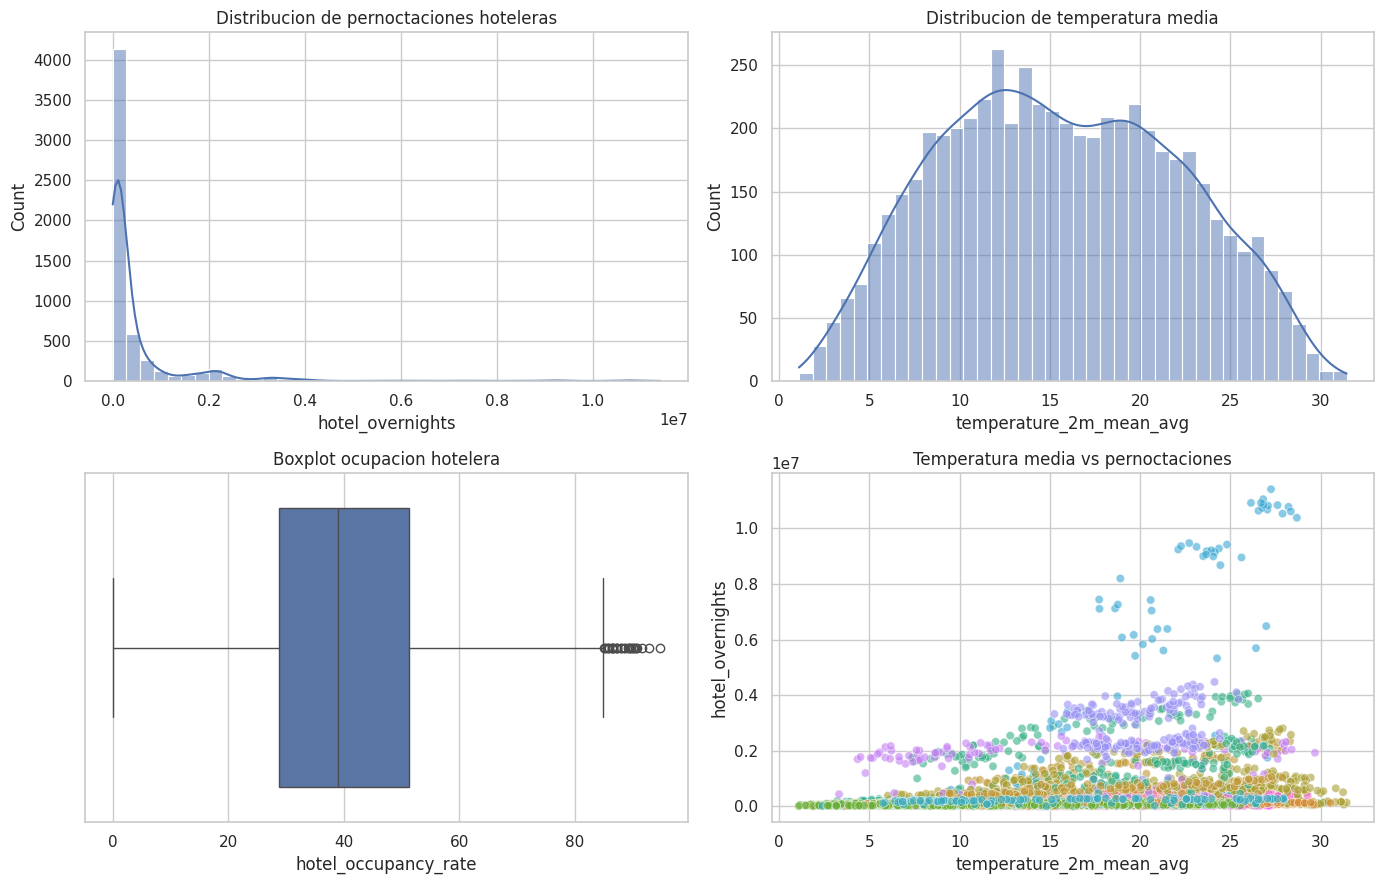

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(gold["hotel_overnights"].dropna(), bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribucion de pernoctaciones hoteleras")

sns.histplot(gold["temperature_2m_mean_avg"].dropna(), bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribucion de temperatura media")

sns.boxplot(data=gold, x="hotel_occupancy_rate", ax=axes[1, 0])
axes[1, 0].set_title("Boxplot ocupacion hotelera")

sns.scatterplot(
    data=gold,
    x="temperature_2m_mean_avg",
    y="hotel_overnights",
    hue="region_code",
    legend=False,
    alpha=0.6,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Temperatura media vs pernoctaciones")

plt.tight_layout()
plt.show()


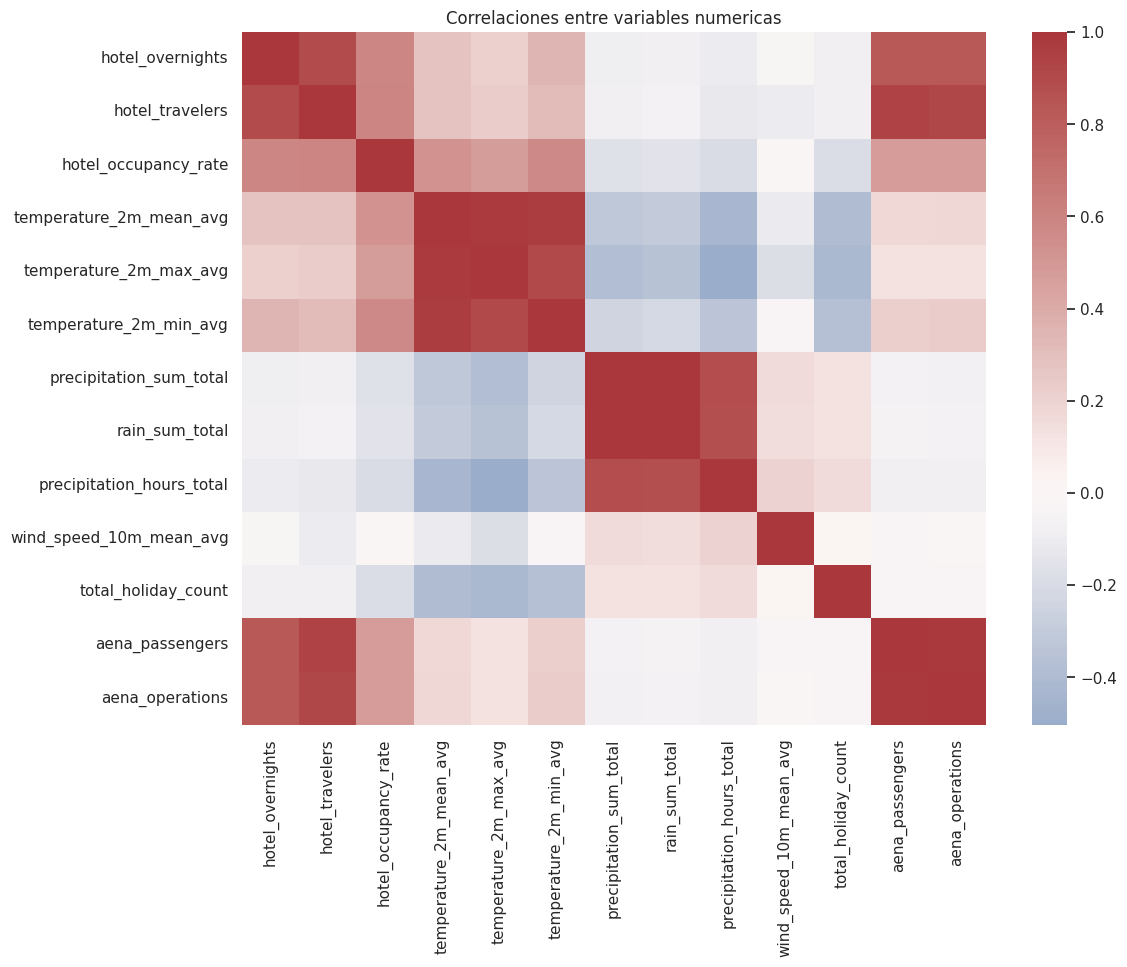

hotel_overnights             1.000
hotel_travelers              0.890
aena_operations              0.832
aena_passengers              0.831
hotel_occupancy_rate         0.584
temperature_2m_min_avg       0.346
temperature_2m_mean_avg      0.283
temperature_2m_max_avg       0.219
wind_speed_10m_mean_avg     -0.043
total_holiday_count         -0.084
rain_sum_total              -0.085
precipitation_sum_total     -0.091
precipitation_hours_total   -0.105
Name: hotel_overnights, dtype: float64

In [15]:
corr_cols = [
    "hotel_overnights",
    "hotel_travelers",
    "hotel_occupancy_rate",
    "temperature_2m_mean_avg",
    "temperature_2m_max_avg",
    "temperature_2m_min_avg",
    "precipitation_sum_total",
    "rain_sum_total",
    "precipitation_hours_total",
    "wind_speed_10m_mean_avg",
    "total_holiday_count",
    "aena_passengers",
    "aena_operations",
]

corr = gold[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, annot=False)
plt.title("Correlaciones entre variables numericas")
plt.show()

corr["hotel_overnights"].sort_values(ascending=False)


## 13. Preparacion del conjunto de datos

Se genera una primera version modelable: se eliminan filas sin target, se crean variables temporales, transformaciones numericas y una division train/test 80/20 por meses completos para respetar el orden temporal.


In [16]:
model_df = gold.dropna(subset=["hotel_overnights"]).copy()
model_df["date"] = pd.to_datetime(model_df["year_month"] + "-01")
model_df["year"] = model_df["date"].dt.year
model_df["month"] = model_df["date"].dt.month
model_df["quarter"] = model_df["date"].dt.quarter
model_df["is_high_season"] = model_df["month"].isin([6, 7, 8, 9]).astype(int)

# Transformaciones para estabilizar distribuciones y capturar relaciones no lineales.
model_df["hotel_overnights_log1p"] = np.log1p(model_df["hotel_overnights"])
model_df["aena_passengers_log1p"] = np.log1p(model_df["aena_passengers"].clip(lower=0))
model_df["precipitation_sqrt"] = np.sqrt(model_df["precipitation_sum_total"].clip(lower=0))
model_df["temperature_2m_mean_sq"] = model_df["temperature_2m_mean_avg"] ** 2

transformation_preview = model_df[[
    "province",
    "year_month",
    "hotel_overnights",
    "hotel_overnights_log1p",
    "aena_passengers",
    "aena_passengers_log1p",
    "precipitation_sum_total",
    "precipitation_sqrt",
    "temperature_2m_mean_avg",
    "temperature_2m_mean_sq",
    "month",
    "quarter",
    "is_high_season",
]].head()

transformation_preview


,province,year_month,hotel_overnights,hotel_overnights_log1p,aena_passengers,aena_passengers_log1p,precipitation_sum_total,precipitation_sqrt,temperature_2m_mean_avg,temperature_2m_mean_sq,month,quarter,is_high_season
0,A Coruna,2015-10,308359.000,12.639,301076,12.615,105.500,10.271,15.358,235.871,10,4,0
1,A Coruna,2015-11,162401.000,11.998,230159,12.347,44.100,6.641,13.970,195.161,11,4,0
2,A Coruna,2015-12,156907.000,11.963,245343,12.410,92.200,9.602,12.813,164.170,12,4,0
3,A Coruna,2016-01,122419.000,11.715,220206,12.302,322.200,17.950,10.987,120.716,1,1,0
4,A Coruna,2016-02,152831.000,11.937,225948,12.328,194.500,13.946,9.841,96.853,2,1,0


### Variables descartadas y criterio

La preparacion se centra en la tabla gold. Algunas columnas se conservan para trazabilidad o analisis, pero no entran directamente como variables numericas del primer dataset modelable.


In [17]:
discarded_variables = pd.DataFrame([
    {"column": "feature_source", "criterion": "Trazabilidad; valor constante en la tabla gold actual."},
    {"column": "target_available", "criterion": "Indicador auxiliar usado para filtrar filas sin target."},
    {"column": "date", "criterion": "Variable auxiliar; se descompone en year/month/quarter."},
    {"column": "year_month", "criterion": "Clave temporal; se usa para ordenar y dividir, no como feature directa."},
    {"column": "hotel_overnights_log1p", "criterion": "Transformacion exploratoria del target; no se usa como feature para evitar fuga."},
    {"column": "hotel_travelers", "criterion": "Muy correlacionada con el target; se reserva para analisis y posibles experimentos posteriores."},
    {"column": "hotel_occupancy_rate", "criterion": "Target alternativo/variable turistica; no se incluye en el baseline para evitar mezclar medidas directas de demanda."},
])

discarded_variables


,column,criterion
0,feature_source,Trazabilidad; valor constante en la tabla gold...
1,target_available,Indicador auxiliar usado para filtrar filas si...
2,date,Variable auxiliar; se descompone en year/month...
3,year_month,"Clave temporal; se usa para ordenar y dividir,..."
4,hotel_overnights_log1p,Transformacion exploratoria del target; no se ...
5,hotel_travelers,Muy correlacionada con el target; se reserva p...
6,hotel_occupancy_rate,Target alternativo/variable turistica; no se i...


### Imputacion, transformaciones, discretizacion, encoding y escalado

Para el modelado se eliminan filas sin target, porque imputar la variable objetivo introduciria informacion inventada. 
Sobre la tabla gold se crean variables de fecha (`year`, `month`, `quarter`, temporada alta), transformaciones numericas (`log1p`, `sqrt`, cuadrado), 
discretizaciones interpretables de temperatura, precipitacion y demanda, y una preparacion reproducible: mediana en variables numericas, valor `unknown` en categoricas, One-Hot Encoding y StandardScaler.


In [18]:
model_df["temperature_bucket"] = pd.cut(
    model_df["temperature_2m_mean_avg"],
    bins=[-np.inf, 10, 18, 25, np.inf],
    labels=["cold", "mild", "warm", "hot"],
)
model_df["precipitation_bucket"] = pd.cut(
    model_df["precipitation_sum_total"],
    bins=[-0.001, 20, 80, np.inf],
    labels=["dry", "normal", "rainy"],
)
model_df["demand_segment"] = pd.qcut(
    model_df["hotel_overnights"],
    q=4,
    labels=["low", "medium", "high", "very_high"],
    duplicates="drop",
)

model_df[[
    "province",
    "year_month",
    "temperature_2m_mean_avg",
    "temperature_bucket",
    "precipitation_sum_total",
    "precipitation_bucket",
    "hotel_overnights",
    "demand_segment",
]].head()


,province,year_month,temperature_2m_mean_avg,temperature_bucket,precipitation_sum_total,precipitation_bucket,hotel_overnights,demand_segment
0,A Coruna,2015-10,15.358,mild,105.500,rainy,308359.000,high
1,A Coruna,2015-11,13.970,mild,44.100,normal,162401.000,high
2,A Coruna,2015-12,12.813,mild,92.200,rainy,156907.000,high
3,A Coruna,2016-01,10.987,mild,322.200,rainy,122419.000,high
4,A Coruna,2016-02,9.841,cold,194.500,rainy,152831.000,high


In [19]:
numeric_feature_cols = [
    "temperature_2m_mean_avg",
    "temperature_2m_max_avg",
    "temperature_2m_min_avg",
    "precipitation_sum_total",
    "rain_sum_total",
    "precipitation_hours_total",
    "wind_speed_10m_mean_avg",
    "wind_speed_10m_max_avg",
    "national_holiday_count",
    "regional_holiday_count",
    "total_holiday_count",
    "aena_passengers",
    "aena_operations",
    "aena_cargo_kg",
    "aena_airport_count",
    "month",
    "quarter",
    "is_high_season",
    "aena_passengers_log1p",
    "temperature_2m_mean_sq",
    "precipitation_sqrt",
]

categorical_feature_cols = [
    "province",
    "region_code",
    "temperature_bucket",
    "precipitation_bucket",
]

feature_cols = numeric_feature_cols + categorical_feature_cols
target_col = "hotel_overnights"
model_df = model_df.sort_values(["date", "province"]).reset_index(drop=True)

# Split temporal por meses completos para evitar que el mismo mes aparezca en train y test.
unique_months = sorted(model_df["year_month"].unique())
month_split_index = int(len(unique_months) * 0.8)
train_months = set(unique_months[:month_split_index])
test_months = set(unique_months[month_split_index:])

train_df = model_df[model_df["year_month"].isin(train_months)].copy()
test_df = model_df[model_df["year_month"].isin(test_months)].copy()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_feature_cols),
        ("categorical", categorical_transformer, categorical_feature_cols),
    ]
)

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

preprocessor.fit(X_train)
X_train_prepared = preprocessor.transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

prepared_feature_names = preprocessor.get_feature_names_out()
X_train_prepared_dense = (
    X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
)
X_test_prepared_dense = (
    X_test_prepared.toarray() if hasattr(X_test_prepared, "toarray") else X_test_prepared
)

prepared_summary = pd.Series({
    "train_rows": X_train_prepared.shape[0],
    "test_rows": X_test_prepared.shape[0],
    "train_pct": round(X_train_prepared.shape[0] / len(model_df), 3),
    "test_pct": round(X_test_prepared.shape[0] / len(model_df), 3),
    "prepared_features": X_train_prepared.shape[1],
    "train_month_min": train_df["year_month"].min(),
    "train_month_max": train_df["year_month"].max(),
    "test_month_min": test_df["year_month"].min(),
    "test_month_max": test_df["year_month"].max(),
    "month_overlap": len(train_months & test_months),
})
display(prepared_summary)

prepared_train_preview = pd.DataFrame(
    X_train_prepared_dense[:5],
    columns=prepared_feature_names,
    index=X_train.index[:5],
)
prepared_train_preview


train_rows              4562
test_rows               1196
train_pct              0.792
test_pct               0.208
prepared_features         99
train_month_min      2015-10
train_month_max      2023-01
test_month_min       2023-02
test_month_max       2024-12
month_overlap              0
dtype: object

,numeric__temperature_2m_mean_avg,numeric__temperature_2m_max_avg,numeric__temperature_2m_min_avg,numeric__precipitation_sum_total,numeric__rain_sum_total,numeric__precipitation_hours_total,numeric__wind_speed_10m_mean_avg,numeric__wind_speed_10m_max_avg,numeric__national_holiday_count,numeric__regional_holiday_count,numeric__total_holiday_count,numeric__aena_passengers,numeric__aena_operations,numeric__aena_cargo_kg,numeric__aena_airport_count,numeric__month,numeric__quarter,numeric__is_high_season,numeric__aena_passengers_log1p,numeric__temperature_2m_mean_sq,numeric__precipitation_sqrt,categorical__province_A Coruna,categorical__province_Alava,categorical__province_Albacete,categorical__province_Alicante,categorical__province_Almeria,categorical__province_Asturias,categorical__province_Avila,categorical__province_Badajoz,categorical__province_Barcelona,categorical__province_Bizkaia,categorical__province_Burgos,categorical__province_Caceres,categorical__province_Cadiz,categorical__province_Cantabria,categorical__province_Castellon,categorical__province_Ceuta,categorical__province_Ciudad Real,categorical__province_Cordoba,categorical__province_Cuenca,...,categorical__province_Palencia,categorical__province_Pontevedra,categorical__province_Salamanca,categorical__province_Santa Cruz de Tenerife,categorical__province_Segovia,categorical__province_Sevilla,categorical__province_Soria,categorical__province_Tarragona,categorical__province_Teruel,categorical__province_Toledo,categorical__province_Valencia,categorical__province_Valladolid,categorical__province_Zamora,categorical__province_Zaragoza,categorical__region_code_AN,categorical__region_code_AR,categorical__region_code_AS,categorical__region_code_CB,categorical__region_code_CE,categorical__region_code_CL,categorical__region_code_CM,categorical__region_code_CN,categorical__region_code_CT,categorical__region_code_EX,categorical__region_code_GA,categorical__region_code_IB,categorical__region_code_MC,categorical__region_code_MD,categorical__region_code_ML,categorical__region_code_NC,categorical__region_code_PV,categorical__region_code_RI,categorical__region_code_VC,categorical__temperature_bucket_cold,categorical__temperature_bucket_hot,categorical__temperature_bucket_mild,categorical__temperature_bucket_warm,categorical__precipitation_bucket_dry,categorical__precipitation_bucket_normal,categorical__precipitation_bucket_rainy
0,-0.002,-0.295,0.297,0.974,1.014,1.341,1.893,1.485,0.342,-0.572,-0.032,-0.035,-0.011,-0.205,1.095,0.965,1.286,-0.682,1.038,-0.205,1.125,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
1,-0.401,-0.429,-0.309,0.204,0.229,0.519,-0.571,-0.869,0.342,-0.572,-0.032,-0.362,-0.341,0.458,0.074,0.965,1.286,-0.682,-0.094,-0.552,0.465,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000
2,0.024,0.054,0.019,-0.438,-0.424,-0.207,-0.270,-0.524,0.342,-0.572,-0.032,-0.363,-0.410,-0.243,0.074,0.965,1.286,-0.682,-0.247,-0.181,-0.288,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000
3,0.645,0.311,0.976,0.520,0.551,0.354,-1.364,-1.592,0.342,1.318,1.002,0.755,0.524,-0.179,0.0

## 14. Dataset gold preparado para modelado

La tabla gold nos proporciona `province + year_month`, el target `hotel_overnights` y las variables explicativas de clima, calendario y movilidad. A partir de ella se genera un conjunto modelable con imputacion, transformaciones numericas, discretizacion, encoding categorico, escalado y division temporal train/test.


## 15. Modelos previstos

Para empezar, se utilizaran modelos de regresion tabular:

- `Ridge` como baseline lineal.
- `RandomForestRegressor` como modelo no lineal interpretable.
- `XGBoostRegressor` si se incorpora como mejora para datos tabulares.

La evaluacion debe respetar el componente temporal, evitando que meses futuros entrenen predicciones de meses pasados.
